# Exercise B.1 — Exploitation versus exploration and population diversity

**string search genetic algorithm:**
- tournament selection with a tunable parameter K,
- your own target string of length L of (approximately) 15 characters,
- an alphabet Σ containing all 26 lowercase letters and all 26 capital letters,
- crossover with probability pc = 1,
- a tunable mutation rate µ,
- a population size N = 200
- a fitness as defined in the lecture
- generational replacement with no elitism. Note: since you are doing crossover between two parents, you will now generate two new children at once, so to get a new population of N strings you need to repeat this
N/2 times.

1. Using K = 2 and µ = 1/L, run the algorithm 10 times to measure the time tfinish (in generations) needed to find the target.
2. Repeat the experiment at both µ = 0 and µ = 3/L. Do you find the target? Explain your observations. (Hint: you may want to stop trying after some predefined number Gmax of generations – I suggest 100). Visualize the distributions of tfinish for each µ (I would suggest a so-called beeswarm plot).
3. Rerun 1-2 above, but now also analyze population diversity throughout the run (e.g. every 10 generations) and at the end. See Appendix.
4. What do you conclude about the influence of µ on algorithm performance and population diversity?
5. Starting from µ = 0, gradually increase µ in steps (choose a range of about 10 values that makes sense to you). Plot the relationship between µ and tfinish. What optimal µ do you find?
6. Now set K = 5 and repeat the above experiment. What do you find? Explain your observations.



In [1]:
import matplotlib.pyplot as plt
import numpy as np

from experiments_b1 import (
    TARGET,
    experiment_b1_1,
    experiment_b1_2,
    experiment_b1_3,
    experiment_b1_5,
    experiment_b1_6,
)
from plotting_b1 import (
    plot_fitness_curves,
    plot_beeswarm,
    plot_diversity,
    plot_mu_vs_tfinish,
    plot_mu_sweep_comparison,
)

G_MAX = 200
N_RUNS = 10
L = len(TARGET)
print(f"Target: '{TARGET}' (L={L})")

Target: 'NaturalComputing' (L=16)


## K=2, mu=1/L

In [2]:
results_b1_1 = experiment_b1_1(n_runs=N_RUNS, G_max=G_MAX)

for r in results_b1_1:
    status = r['t_finish'] if r['t_finish'] is not None else f"not found in {G_MAX}"

  Run 1/10: t_finish = 64
  Run 2/10: t_finish = 54
  Run 3/10: t_finish = 44
  Run 4/10: t_finish = 103
  Run 5/10: t_finish = 73
  Run 6/10: t_finish = 64
  Run 7/10: t_finish = 50
  Run 8/10: t_finish = 92
  Run 9/10: t_finish = 42
  Run 10/10: t_finish = 61


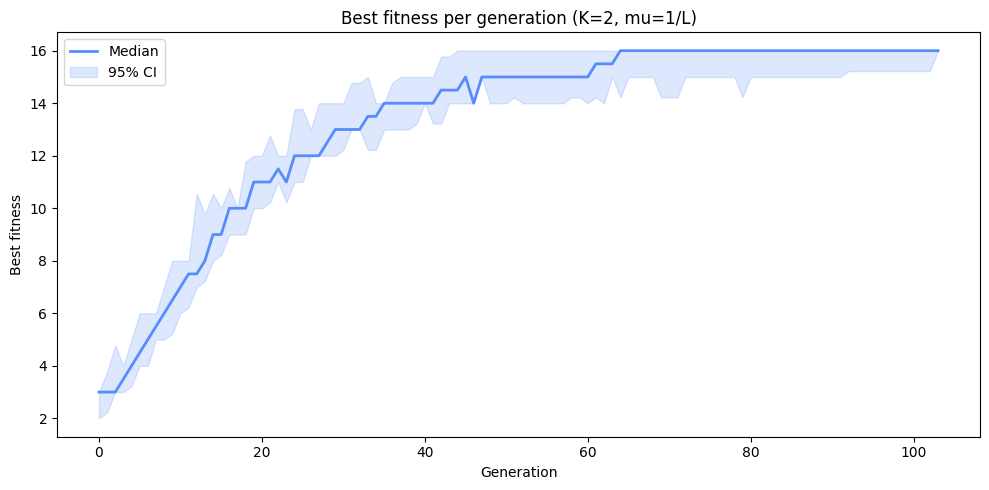

In [3]:
fig = plot_fitness_curves(results_b1_1, title="Best fitness per generation (K=2, mu=1/L)")
plt.show()

## K=2; mu=0, mu=1/L, mu=3/L

In [4]:
results_b1_2 = experiment_b1_2(n_runs=N_RUNS, G_max=G_MAX)

  Running mu=0...
    Found target in 1/10 runs
  Running mu=1/L...
    Found target in 10/10 runs
  Running mu=3/L...
    Found target in 0/10 runs


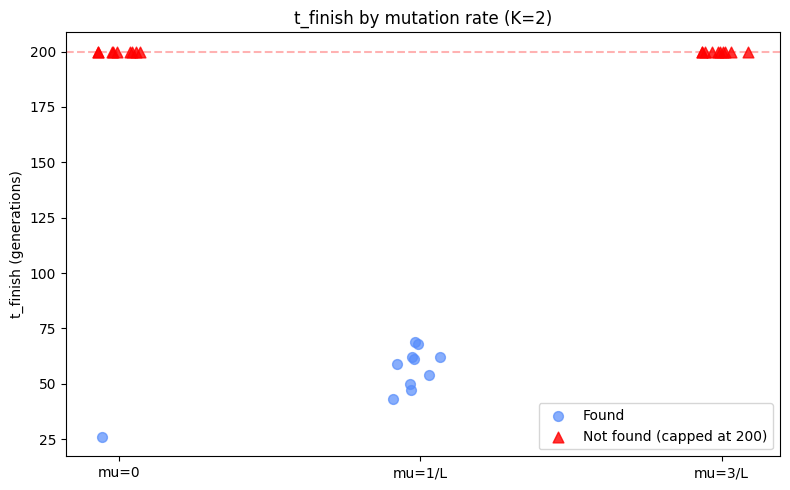

In [5]:
fig = plot_beeswarm(results_b1_2, G_max=G_MAX, title="t_finish by mutation rate (K=2)")
plt.show()

## Population diversity analysis
- Mean Shannon entropy
- Mean pairwise Hamming distance

In [6]:
results_b1_3 = experiment_b1_3(n_runs=N_RUNS, G_max=G_MAX)

  Running mu=0 with diversity tracking...
    Found target in 0/10 runs
  Running mu=1/L with diversity tracking...
    Found target in 10/10 runs
  Running mu=3/L with diversity tracking...
    Found target in 0/10 runs


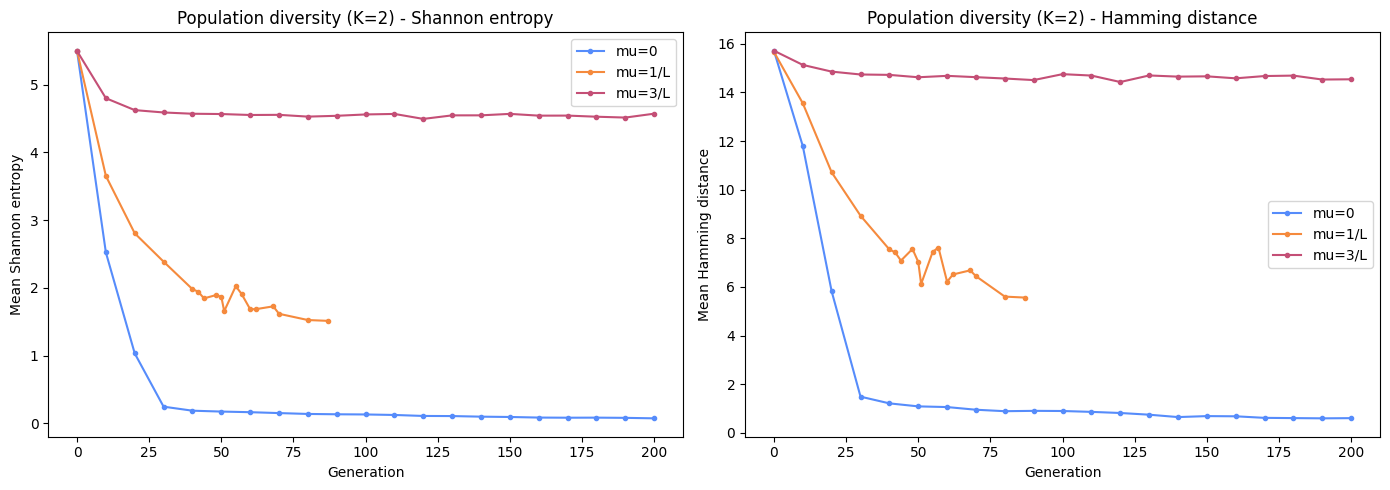

In [7]:
fig = plot_diversity(results_b1_3, title_prefix="Population diversity (K=2)")
plt.show()

In [8]:
from experiments_b1 import experiment_b1_snapshots

snapshots_b1 = experiment_b1_snapshots(G_max=G_MAX, K=2)

for label, snaps in snapshots_b1.items():
    print(f"--- {label} ---")
    for g, s in snaps.items():
        print(f"gen {g:>3}  top by fitness:")
        for seq, f in s["top"]:
            print(f"   [{f:2d}]  {seq}")
        print(f"          random sample:")
        for seq, f in s["rand"]:
            print(f"   [{f:2d}]  {seq}")
    print(f"target:   {TARGET}")
    print()

--- mu=0 ---
gen   0  top by fitness:
   [ 3]  ZZtdZDGCSSpLZbku
   [ 2]  JadkBXxmgWFukINM
   [ 2]  WQIAFasAbIBFtnsc
   [ 2]  vflFbaZMXXpkEQZi
          random sample:
   [ 0]  kixGZSKGcvEEuXVY
   [ 0]  egHqKoxlrvBjZvyH
   [ 0]  KzaRXihayFwIdxXY
gen  10  top by fitness:
   [ 8]  eatmraSCSSpuFqTg
   [ 8]  DatArDGCSWpuFiZg
   [ 7]  eatUIavCrmFufaTg
   [ 7]  BaJurmvCrIIuFiZg
          random sample:
   [ 5]  umeurMGCSIFukINg
   [ 6]  oCtsrmvCSSpuFqTg
   [ 3]  sHJUIavCSXpkkIgS
gen  30  top by fitness:
   [14]  BaturalCSmputing
   [14]  JaturalCSmputing
   [14]  JaturalCSmputing
   [14]  BaturalCrmputing
          random sample:
   [14]  BaturalCSmputing
   [14]  BaturalCrmputing
   [14]  eaturalCSmputing
gen  60  top by fitness:
   [14]  JaturalCrmputing
   [14]  BaturalCSmputing
   [14]  BaturalCSmputing
   [14]  BaturalCSmputing
          random sample:
   [14]  BaturalCrmputing
   [14]  BaturalCrmputing
   [14]  JaturalCrmputing
gen 100  top by fitness:
   [14]  BaturalCrmputing
   [14] 

## find optimal mu (K=2)

In [9]:
results_b1_5 = experiment_b1_5(n_runs=N_RUNS, G_max=G_MAX)

  Running mu = 0.0/L...
    Found target in 0/10 runs
  Running mu = 1.0/L...
    Found target in 10/10 runs
  Running mu = 2.0/L...
    Found target in 0/10 runs
  Running mu = 3.0/L...
    Found target in 0/10 runs
  Running mu = 4.0/L...
    Found target in 0/10 runs
  Running mu = 5.0/L...
    Found target in 0/10 runs
  Running mu = 6.0/L...
    Found target in 0/10 runs
  Running mu = 7.0/L...
    Found target in 0/10 runs
  Running mu = 8.0/L...
    Found target in 0/10 runs
  Running mu = 9.0/L...
    Found target in 0/10 runs
  Running mu = 10.0/L...
    Found target in 0/10 runs


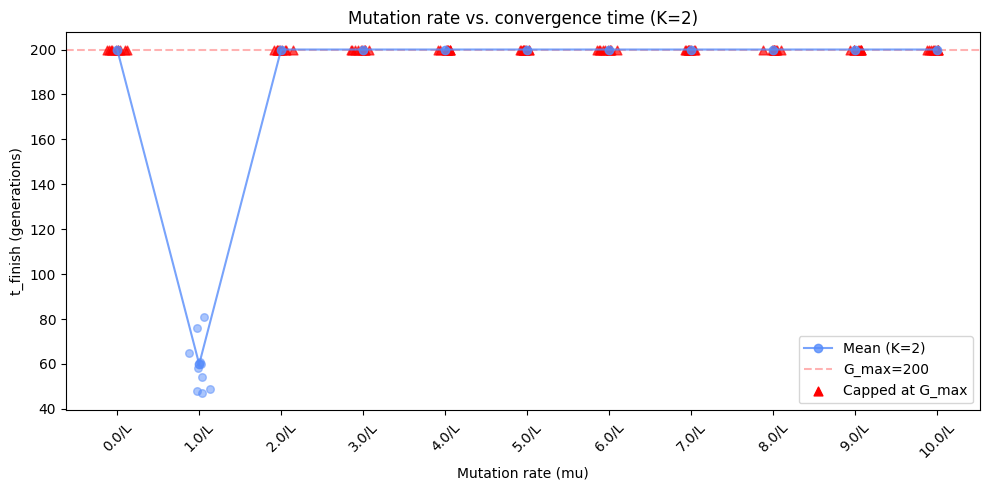

In [10]:
fig = plot_mu_vs_tfinish(results_b1_5, G_max=G_MAX, L=L, K_label="K=2")
plt.show()

## Repeat with K=5

In [11]:
results_b1_6 = experiment_b1_6(n_runs=N_RUNS, G_max=G_MAX)

  Running mu = 0.0/L (K=5)...
    Found target in 0/10 runs
  Running mu = 1.0/L (K=5)...
    Found target in 10/10 runs
  Running mu = 2.0/L (K=5)...
    Found target in 10/10 runs
  Running mu = 3.0/L (K=5)...
    Found target in 0/10 runs
  Running mu = 4.0/L (K=5)...
    Found target in 0/10 runs
  Running mu = 5.0/L (K=5)...
    Found target in 0/10 runs
  Running mu = 6.0/L (K=5)...
    Found target in 0/10 runs
  Running mu = 7.0/L (K=5)...
    Found target in 0/10 runs
  Running mu = 8.0/L (K=5)...
    Found target in 0/10 runs
  Running mu = 9.0/L (K=5)...
    Found target in 0/10 runs
  Running mu = 10.0/L (K=5)...
    Found target in 0/10 runs


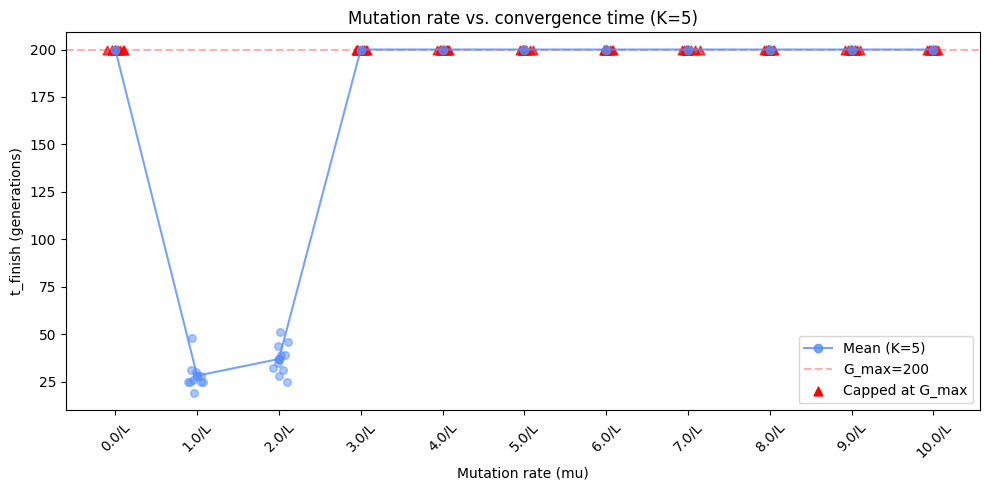

In [12]:
fig = plot_mu_vs_tfinish(results_b1_6, G_max=G_MAX, L=L, K_label="K=5")
plt.show()

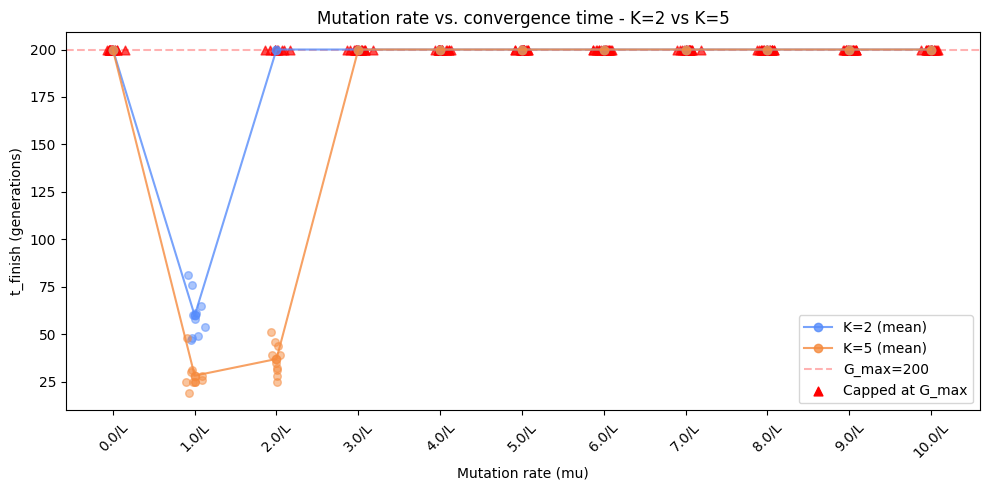

In [13]:
fig = plot_mu_sweep_comparison(results_b1_5, results_b1_6, G_max=G_MAX, L=L)
plt.show()